<a href="https://colab.research.google.com/github/HimanshiChoubal/Major_Project/blob/master/Q3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install -q pennylane

import time, math, random, warnings
import numpy as np
import pandas as pd
import torch, torch.nn as nn
import torchvision
import matplotlib.pyplot as plt
from functools import partial
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")
try:
    import pennylane as qml
    HAS_PL = True
except ImportError:
    HAS_PL = False
    print("PennyLane not found -> falling back to classical surrogate layer.")

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed(42)
DEVICE = torch.device("cpu")   # default.qubit simulator runs on CPU
N_QUBITS = 4

print(f"torch {torch.__version__} | torchvision {torchvision.__version__} | "
      f"pennylane {qml.__version__ if HAS_PL else 'N/A'}")

# ---------------------------------------------------------------------------
# 4-qubit QCNN circuit (re-creation of CELL 4)
# ---------------------------------------------------------------------------
if HAS_PL:
    dev = qml.device("default.qubit", wires=N_QUBITS)

    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def qcnn_circuit(inputs, aqfs_gain, aqfs_phi, conv1, pool, conv2):
        # 1) RY/RZ angle encoding (batched over leading dim of `inputs`)
        for i in range(N_QUBITS):
            qml.RY(inputs[..., i], wires=i)
            qml.RZ(inputs[..., i], wires=i)
        # 2) Adaptive Quantum Feature Saliency (AQFS) block:
        #    learnable per-feature gains (data re-uploading) + trainable entangling ring
        for i in range(N_QUBITS):
            qml.RY(aqfs_gain[i] * inputs[..., i], wires=i)
        for i in range(N_QUBITS):
            qml.CRZ(aqfs_phi[i], wires=[i, (i + 1) % N_QUBITS])
        # 3) Convolution layer 1: SU(4) unitaries on neighbouring pairs
        qml.ArbitraryUnitary(conv1[0], wires=[0, 1])
        qml.ArbitraryUnitary(conv1[1], wires=[2, 3])
        # 4) Pooling: controlled-RY, then qubits 1 and 3 are discarded (partial trace)
        qml.CRY(pool[0], wires=[1, 0])
        qml.CRY(pool[1], wires=[3, 2])
        # 5) Convolution layer 2 on surviving qubits
        qml.ArbitraryUnitary(conv2[0], wires=[0, 2])
        return [qml.expval(qml.PauliZ(0)), qml.expval(qml.PauliZ(2))]

    WEIGHT_SHAPES = {"aqfs_gain": (4,), "aqfs_phi": (4,),
                     "conv1": (2, 15), "pool": (2,), "conv2": (1, 15)}
    INIT = {"aqfs_gain": nn.init.ones_,
            "aqfs_phi": partial(nn.init.normal_, std=0.3),
            "conv1":    partial(nn.init.normal_, std=0.3),
            "pool":     partial(nn.init.normal_, std=0.3),
            "conv2":    partial(nn.init.normal_, std=0.3)}

class ClassicalSurrogateLayer(nn.Module):
    """Fallback with the same I/O shape as the QCNN (4 -> 2, bounded)."""
    def __init__(self):
        super().__init__()
        self.lin = nn.Linear(N_QUBITS, 2)
    def forward(self, x):
        return torch.tanh(self.lin(x))

def build_quantum_layer():
    if HAS_PL:
        return qml.qnn.TorchLayer(qcnn_circuit, WEIGHT_SHAPES, init_method=INIT)
    return ClassicalSurrogateLayer()

# ---------------------------------------------------------------------------
# Hybrid model
# ---------------------------------------------------------------------------
class HybridQCNNClassifier(nn.Module):
    """4 PCA features -> QCNN (2 expectation values) -> Dropout/Linear head -> logit.
    forward() returns logits (use BCEWithLogitsLoss); predict_proba() returns P in [0,1]."""
    def __init__(self, hidden=8, dropout=0.1):
        super().__init__()
        self.qlayer = build_quantum_layer()
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(2, hidden), nn.ReLU(),
            nn.Linear(hidden, 1),
        )
    def forward(self, x):
        z = math.pi * torch.tanh(x.float())      # bound features to rotation range
        q = self.qlayer(z).float()
        return self.head(q).squeeze(-1)
    @torch.no_grad()
    def predict_proba(self, x):
        self.eval()
        return torch.sigmoid(self(x))             # anomaly probability in [0, 1]

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

# ---- smoke test: forward + autograd through the quantum layer ----
_m = HybridQCNNClassifier()
_x = torch.randn(8, 4)
_out = _m(_x); _out.sum().backward()
print("logits shape:", tuple(_out.shape), "| P range:",
      [round(v, 3) for v in (_m.predict_proba(_x).min().item(), _m.predict_proba(_x).max().item())])
print("trainable params:", count_params(_m))
if HAS_PL:
    print("quantum grads OK:", all(p.grad is not None for p in _m.qlayer.parameters()))
del _m, _x, _out

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 48.9 MB/s eta 0:00:00
torch 2.11.0+cpu | torchvision 0.26.0+cpu | pennylane 0.45.1
logits shape: (8,) | P range: [0.454, 0.473]
trainable params: 88
quantum grads OK: True


In [2]:
# ---------------------------------------------------------------------------
# Synthetic dataset (4 PCA features, Class 0 healthy / Class 1 critical)
# ---------------------------------------------------------------------------
GT_DELTA = np.array([1.6, 0.3, 1.4, 0.4])                  # class-mean separation per feature
GT_IMPORTANCE = np.abs(GT_DELTA) / np.abs(GT_DELTA).sum()  # ground-truth feature importance

def make_features(n, seed):
    rng = np.random.default_rng(seed)
    y = rng.integers(0, 2, size=n)
    x = rng.normal(0, 0.8, size=(n, 4))
    x[:, 1] += 0.3 * x[:, 0]                               # mild feature correlation
    x += (y[:, None] - 0.5) * GT_DELTA                     # class-conditional shift
    return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

def apply_atmospheric_noise(X, sigma, seed=0):
    """Haze (signal attenuation) + sensor/atmospheric Gaussian noise."""
    g = torch.Generator().manual_seed(seed)
    haze = min(0.4 * sigma, 0.8)
    return X * (1 - haze) + sigma * torch.randn(X.shape, generator=g)

X_tr, y_tr = make_features(512, seed=1)
X_va, y_va = make_features(128, seed=2)
X_te, y_te = make_features(256, seed=3)

BATCH = 32
def make_loader(X, y, shuffle, seed=0):
    return DataLoader(TensorDataset(X, y), batch_size=BATCH, shuffle=shuffle,
                      generator=torch.Generator().manual_seed(seed))
train_loader = make_loader(X_tr, y_tr, True)
val_loader   = make_loader(X_va, y_va, False)

# ---------------------------------------------------------------------------
# Metrics + generic trainer (reused for the classical baseline in CELL 7)
# ---------------------------------------------------------------------------
def acc_f1(logits, y):
    pred = (torch.sigmoid(logits) >= 0.5).float()
    tp = ((pred == 1) & (y == 1)).sum().item()
    fp = ((pred == 1) & (y == 0)).sum().item()
    fn = ((pred == 0) & (y == 1)).sum().item()
    acc = (pred == y).float().mean().item()
    f1 = 2 * tp / (2 * tp + fp + fn + 1e-12)
    return acc, f1

def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total, n, all_logits, all_y = 0.0, 0, [], []
    with torch.set_grad_enabled(training):
        for xb, yb in loader:
            logits = model(xb)
            loss = criterion(logits, yb)
            if training:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total += loss.item() * len(yb); n += len(yb)
            all_logits.append(logits.detach()); all_y.append(yb)
    acc, f1 = acc_f1(torch.cat(all_logits), torch.cat(all_y))
    return total / n, acc, f1

def train_model(model, name, train_loader, val_loader, epochs=10, lr=0.05, verbose=True):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    keys = ["epoch", "train_loss", "train_acc", "train_f1",
            "val_loss", "val_acc", "val_f1", "time_s"]
    hist = {k: [] for k in keys}
    for ep in range(1, epochs + 1):
        t0 = time.time()
        tl, ta, tf = run_epoch(model, train_loader, criterion, optimizer)
        vl, va, vf = run_epoch(model, val_loader, criterion)
        dt = time.time() - t0
        for k, v in zip(keys, [ep, tl, ta, tf, vl, va, vf, dt]):
            hist[k].append(float(v))
        if verbose:
            print(f"[{name}] ep {ep:02d}/{epochs} | loss {tl:.4f} acc {ta:.3f} f1 {tf:.3f} "
                  f"| val loss {vl:.4f} acc {va:.3f} f1 {vf:.3f} | {dt:.2f}s")
    return hist

@torch.no_grad()
def evaluate(model, X, y):
    model.eval()
    return acc_f1(model(X), y)

# ---------------------------------------------------------------------------
# Train the hybrid QCNN
# ---------------------------------------------------------------------------
EPOCHS, LR = 10, 0.05
set_seed(42)
qmodel = HybridQCNNClassifier()
print(f"Hybrid QCNN trainable parameters: {count_params(qmodel)}\n")
q_hist = train_model(qmodel, "QCNN", train_loader, val_loader, epochs=EPOCHS, lr=LR)

q_df = pd.DataFrame(q_hist).set_index("epoch").round(4)
display(q_df)
q_test_acc, q_test_f1 = evaluate(qmodel, X_te, y_te)
print(f"\nQCNN test  | accuracy: {q_test_acc:.4f} | F1: {q_test_f1:.4f} | "
      f"total train time: {sum(q_hist['time_s']):.1f}s")

Hybrid QCNN trainable parameters: 88

[QCNN] ep 01/10 | loss 0.6424 acc 0.633 f1 0.654 | val loss 0.5377 acc 0.812 f1 0.810 | 2.16s
[QCNN] ep 02/10 | loss 0.4199 acc 0.842 f1 0.846 | val loss 0.6318 acc 0.773 f1 0.743 | 1.95s
[QCNN] ep 03/10 | loss 0.3932 acc 0.826 f1 0.832 | val loss 0.4975 acc 0.805 f1 0.797 | 0.91s
[QCNN] ep 04/10 | loss 0.3887 acc 0.852 f1 0.856 | val loss 0.5382 acc 0.797 f1 0.787 | 0.90s
[QCNN] ep 05/10 | loss 0.3670 acc 0.855 f1 0.856 | val loss 0.4892 acc 0.781 f1 0.794 | 0.96s
[QCNN] ep 06/10 | loss 0.3841 acc 0.846 f1 0.852 | val loss 0.4867 acc 0.820 f1 0.816 | 1.00s
[QCNN] ep 07/10 | loss 0.3644 acc 0.861 f1 0.866 | val loss 0.4820 acc 0.789 f1 0.791 | 0.93s
[QCNN] ep 08/10 | loss 0.3589 acc 0.850 f1 0.856 | val loss 0.4788 acc 0.820 f1 0.816 | 1.18s
[QCNN] ep 09/10 | loss 0.3562 acc 0.859 f1 0.865 | val loss 0.5065 acc 0.805 f1 0.793 | 1.19s
[QCNN] ep 10/10 | loss 0.3544 acc 0.871 f1 0.875 | val loss 0.4934 acc 0.836 f1 0.832 | 0.93s


,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1,time_s
epoch,,,,,,,
1.0,0.6424,0.6328,0.6544,0.5377,0.8125,0.8095,2.1622
2.0,0.4199,0.8418,0.8457,0.6318,0.7734,0.7434,1.9493
3.0,0.3932,0.8262,0.8324,0.4975,0.8047,0.7967,0.9078
4.0,0.3887,0.8516,0.8561,0.5382,0.7969,0.7869,0.8986
5.0,0.3670,0.8555,0.8560,0.4892,0.7812,0.7941,0.9645
6.0,0.3841,0.8457,0.8523,0.4867,0.8203,0.8160,1.0026
7.0,0.3644,0.8613,0.8658,0.4820,0.7891,0.7907,0.9346
8.0,0.3589,0.8496,0.8555,0.4788,0.8203,0.8160,1.1794
9.0,0.3562,0.8594,0.8647,0.5065,0.8047,0.7934,1.1878



QCNN test  | accuracy: 0.8242 | F1: 0.8276 | total train time: 12.1s


QCNN params: 88 | MLP hidden=6, params: 79

[MLP ] ep 01/10 | loss 0.3825 acc 0.799 f1 0.822 | val loss 0.3720 acc 0.875 f1 0.871 | 0.03s
[MLP ] ep 02/10 | loss 0.3059 acc 0.908 f1 0.908 | val loss 0.2730 acc 0.898 f1 0.898 | 0.04s
[MLP ] ep 03/10 | loss 0.2578 acc 0.910 f1 0.911 | val loss 0.2750 acc 0.883 f1 0.884 | 0.04s
[MLP ] ep 04/10 | loss 0.2540 acc 0.918 f1 0.920 | val loss 0.2668 acc 0.883 f1 0.884 | 0.03s
[MLP ] ep 05/10 | loss 0.2453 acc 0.916 f1 0.916 | val loss 0.2706 acc 0.891 f1 0.889 | 0.05s
[MLP ] ep 06/10 | loss 0.2434 acc 0.916 f1 0.916 | val loss 0.2660 acc 0.898 f1 0.896 | 0.04s
[MLP ] ep 07/10 | loss 0.2484 acc 0.916 f1 0.917 | val loss 0.2592 acc 0.891 f1 0.891 | 0.04s
[MLP ] ep 08/10 | loss 0.2446 acc 0.910 f1 0.911 | val loss 0.2563 acc 0.891 f1 0.894 | 0.03s
[MLP ] ep 09/10 | loss 0.2436 acc 0.914 f1 0.917 | val loss 0.2812 acc 0.883 f1 0.885 | 0.04s
[MLP ] ep 10/10 | loss 0.2434 acc 0.902 f1 0.905 | val loss 0.2647 acc 0.898 f1 0.901 | 0.04s


,Model,Params,Test Acc,Test F1,Train time (s)
0,Hybrid QCNN,88,0.8242,0.8276,12.1219
1,Classical MLP,79,0.8945,0.9011,0.3885


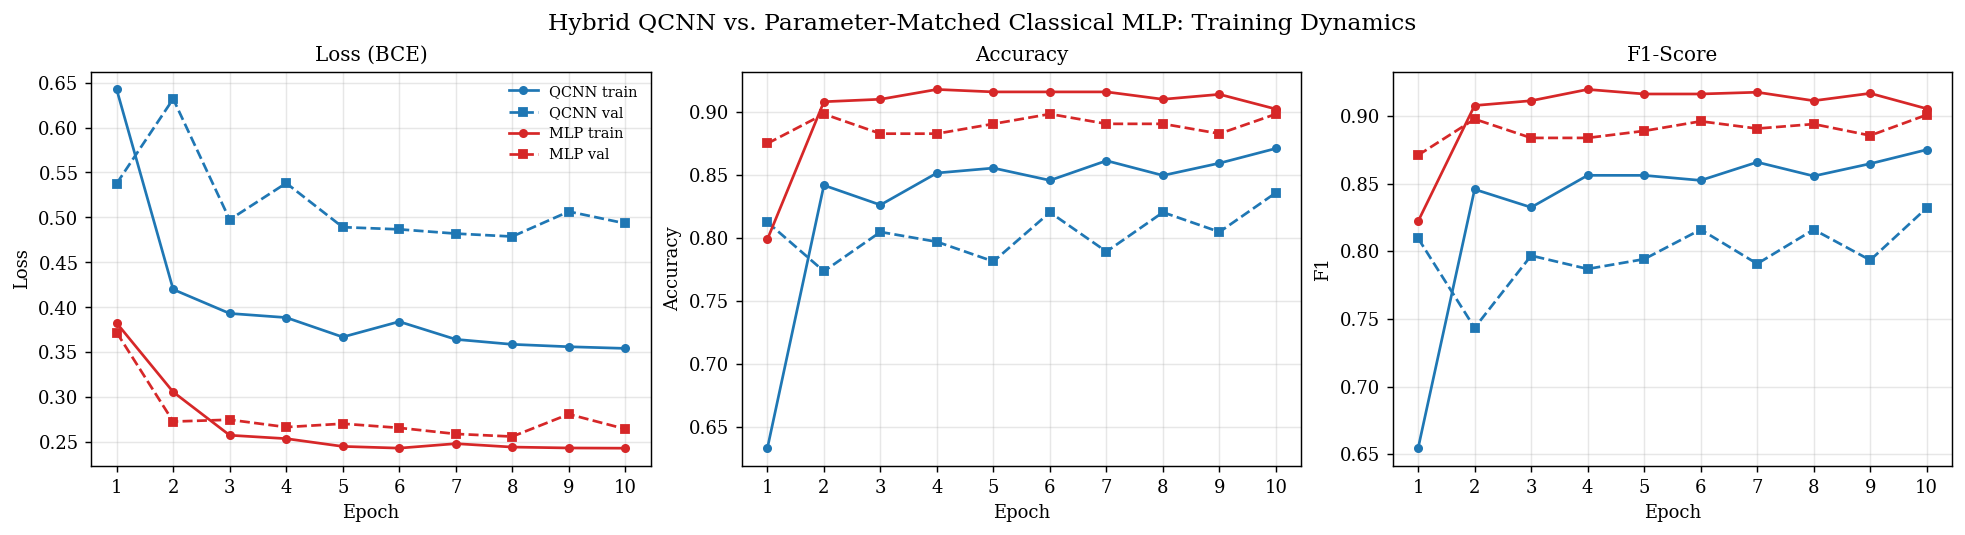

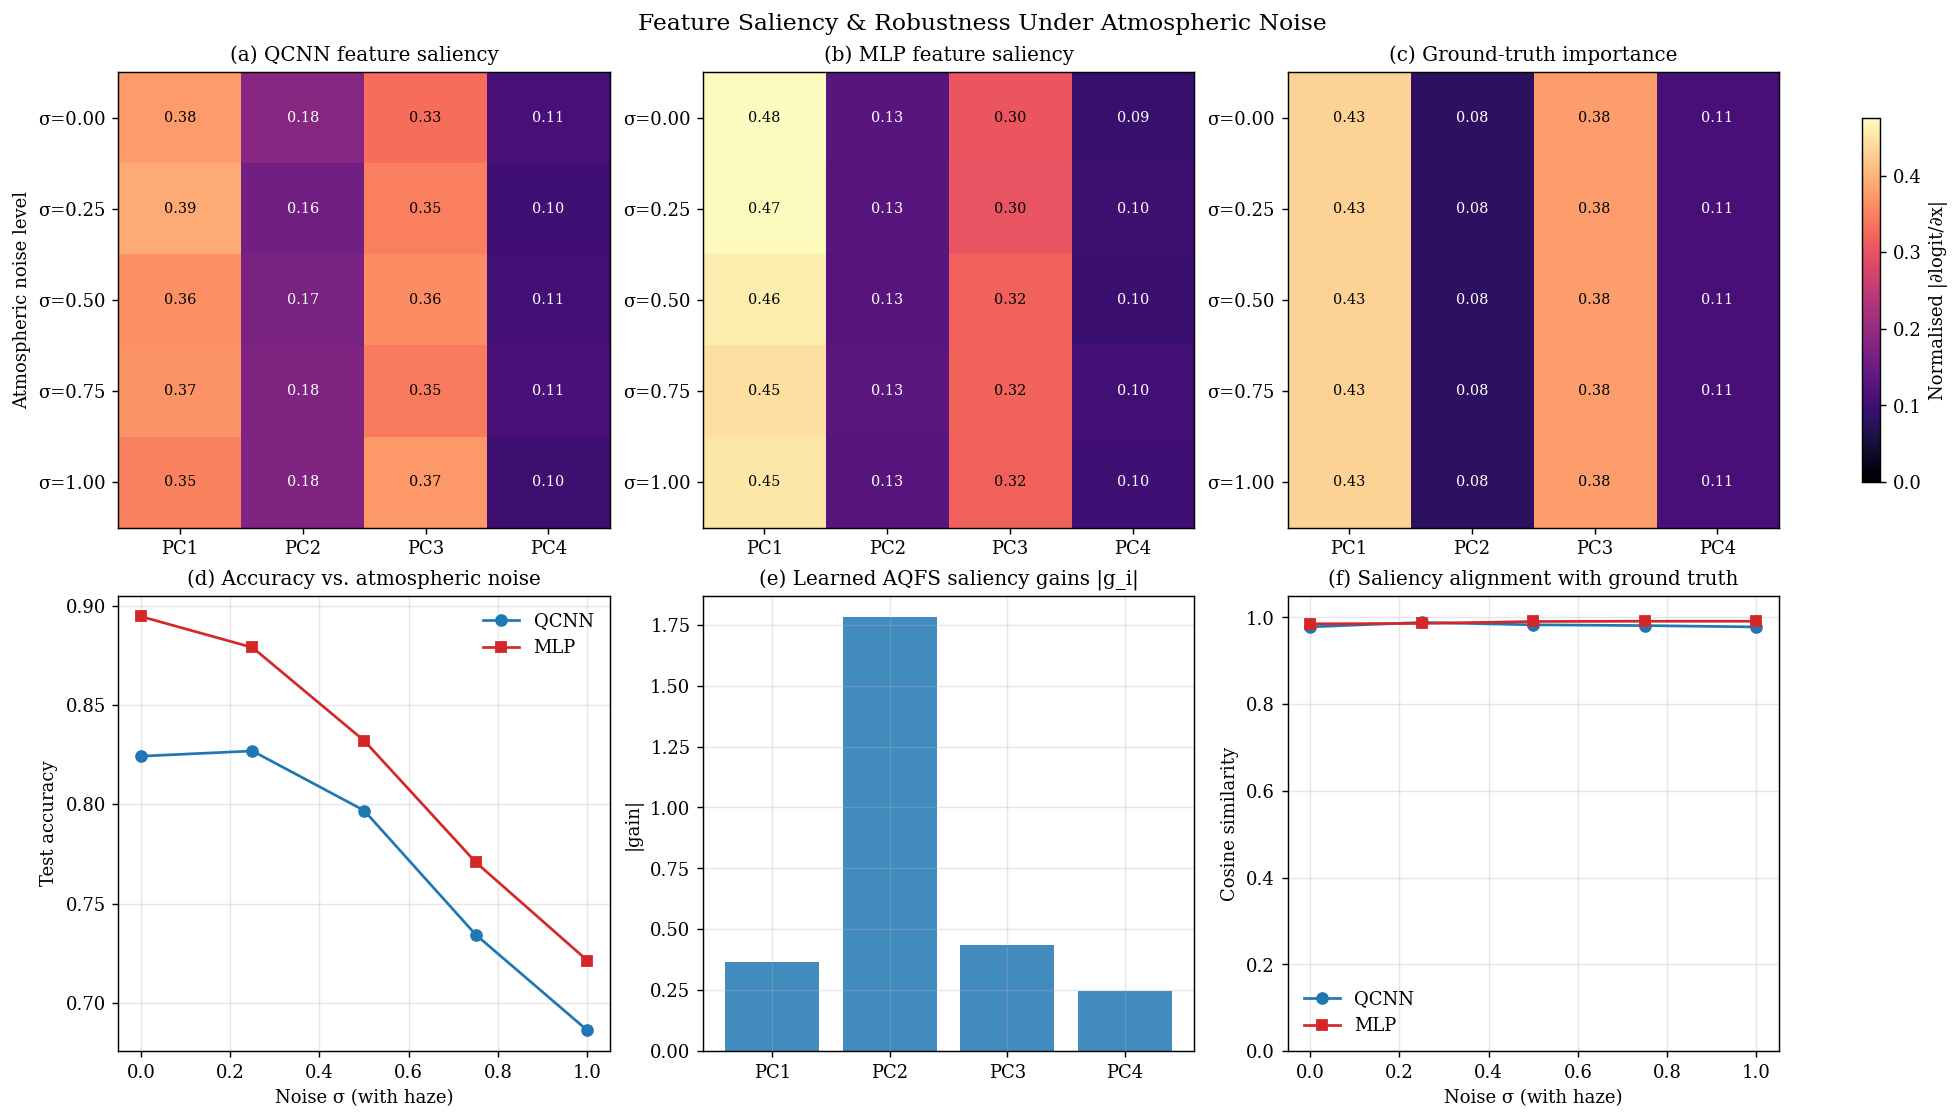

Saved: fig1_training_curves.png, fig2_saliency_robustness.png


In [3]:
# ---------------------------------------------------------------------------
# Parameter-matched classical MLP baseline
# ---------------------------------------------------------------------------
class ClassicalMLPBaseline(nn.Module):
    def __init__(self, hidden, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )
    def forward(self, x):
        return self.net(math.pi * torch.tanh(x.float())).squeeze(-1)  # same input scaling

target = count_params(qmodel)
best_h = min(range(2, 65), key=lambda h: abs(count_params(ClassicalMLPBaseline(h)) - target))
set_seed(42)
cmodel = ClassicalMLPBaseline(best_h)
print(f"QCNN params: {target} | MLP hidden={best_h}, params: {count_params(cmodel)}\n")

c_hist = train_model(cmodel, "MLP ", train_loader, val_loader, epochs=EPOCHS, lr=LR)
c_test_acc, c_test_f1 = evaluate(cmodel, X_te, y_te)

summary = pd.DataFrame({
    "Model": ["Hybrid QCNN", "Classical MLP"],
    "Params": [count_params(qmodel), count_params(cmodel)],
    "Test Acc": [q_test_acc, c_test_acc],
    "Test F1": [q_test_f1, c_test_f1],
    "Train time (s)": [sum(q_hist["time_s"]), sum(c_hist["time_s"])],
}).round(4)
display(summary)

# ---------------------------------------------------------------------------
# Robustness + saliency under atmospheric noise
# ---------------------------------------------------------------------------
NOISE_LEVELS = [0.0, 0.25, 0.5, 0.75, 1.0]

def input_saliency(model, X):
    """Mean |d logit / d x| per feature, normalised to sum to 1."""
    model.eval()
    x = X.clone().requires_grad_(True)
    (g,) = torch.autograd.grad(model(x).sum(), x)
    s = g.abs().mean(0).detach().numpy()
    return s / (s.sum() + 1e-12)

def cosine(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))

X_crit = X_te[y_te == 1]
acc_q, acc_c, sal_q, sal_c = [], [], [], []
for s in NOISE_LEVELS:
    aq, ac = [], []
    for rep in range(3):                                   # average over 3 noise draws
        Xn = apply_atmospheric_noise(X_te, s, seed=100 + rep)
        aq.append(evaluate(qmodel, Xn, y_te)[0]); ac.append(evaluate(cmodel, Xn, y_te)[0])
    acc_q.append(np.mean(aq)); acc_c.append(np.mean(ac))
    Xc = apply_atmospheric_noise(X_crit, s, seed=7)
    sal_q.append(input_saliency(qmodel, Xc)); sal_c.append(input_saliency(cmodel, Xc))

acc_q, acc_c = np.array(acc_q), np.array(acc_c)
sal_q, sal_c = np.stack(sal_q), np.stack(sal_c)            # (n_levels, 4)
cos_q = np.array([cosine(r, GT_IMPORTANCE) for r in sal_q])
cos_c = np.array([cosine(r, GT_IMPORTANCE) for r in sal_c])

# ---------------------------------------------------------------------------
# Publication-style figures
# ---------------------------------------------------------------------------
plt.rcParams.update({"font.family": "serif", "font.size": 10, "axes.titlesize": 11,
                     "axes.labelsize": 10, "axes.grid": True, "grid.alpha": 0.3,
                     "figure.dpi": 130, "savefig.dpi": 300})
QC, CC = "#1f77b4", "#d62728"
ep = np.array(q_hist["epoch"])

# ---- Figure 1: training curves ----
fig1, axs = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, key, title, ylab in [(axs[0], "loss", "Loss (BCE)", "Loss"),
                             (axs[1], "acc", "Accuracy", "Accuracy"),
                             (axs[2], "f1", "F1-Score", "F1")]:
    ax.plot(ep, q_hist[f"train_{key}"], "-o", c=QC, ms=4, label="QCNN train")
    ax.plot(ep, q_hist[f"val_{key}"],   "--s", c=QC, ms=4, label="QCNN val")
    ax.plot(ep, c_hist[f"train_{key}"], "-o", c=CC, ms=4, label="MLP train")
    ax.plot(ep, c_hist[f"val_{key}"],   "--s", c=CC, ms=4, label="MLP val")
    ax.set(title=title, xlabel="Epoch", ylabel=ylab, xticks=ep)
axs[0].legend(frameon=False, fontsize=8)
fig1.suptitle("Hybrid QCNN vs. Parameter-Matched Classical MLP: Training Dynamics", fontsize=13)
fig1.savefig("fig1_training_curves.png", bbox_inches="tight")
plt.show()

# ---- Figure 2: saliency / robustness grid ----
fig2, axs = plt.subplots(2, 3, figsize=(15, 8.5), constrained_layout=True)
FEATS = ["PC1", "PC2", "PC3", "PC4"]
gt_mat = np.tile(GT_IMPORTANCE, (len(NOISE_LEVELS), 1))
vmax = max(sal_q.max(), sal_c.max(), gt_mat.max())

def heat(ax, M, title):
    im = ax.imshow(M, cmap="magma", vmin=0, vmax=vmax, aspect="auto")
    ax.set(title=title, xticks=range(4), xticklabels=FEATS,
           yticks=range(len(NOISE_LEVELS)), yticklabels=[f"σ={s:.2f}" for s in NOISE_LEVELS])
    ax.grid(False)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center",
                    color="white" if M[i, j] < 0.6 * vmax else "black", fontsize=8)
    return im

im = heat(axs[0, 0], sal_q, "(a) QCNN feature saliency")
heat(axs[0, 1], sal_c, "(b) MLP feature saliency")
heat(axs[0, 2], gt_mat, "(c) Ground-truth importance")
fig2.colorbar(im, ax=axs[0, :], shrink=0.8, label="Normalised |∂logit/∂x|")
axs[0, 0].set_ylabel("Atmospheric noise level")

axs[1, 0].plot(NOISE_LEVELS, acc_q, "-o", c=QC, label="QCNN")
axs[1, 0].plot(NOISE_LEVELS, acc_c, "-s", c=CC, label="MLP")
axs[1, 0].set(title="(d) Accuracy vs. atmospheric noise", xlabel="Noise σ (with haze)",
              ylabel="Test accuracy"); axs[1, 0].legend(frameon=False)

if hasattr(qmodel.qlayer, "qnode_weights"):
    gains = qmodel.qlayer.qnode_weights["aqfs_gain"].detach().abs().numpy()
else:
    gains = np.zeros(4)
axs[1, 1].bar(FEATS, gains, color=QC, alpha=0.85)
axs[1, 1].set(title="(e) Learned AQFS saliency gains |g_i|", ylabel="|gain|")

axs[1, 2].plot(NOISE_LEVELS, cos_q, "-o", c=QC, label="QCNN")
axs[1, 2].plot(NOISE_LEVELS, cos_c, "-s", c=CC, label="MLP")
axs[1, 2].set(title="(f) Saliency alignment with ground truth", xlabel="Noise σ (with haze)",
              ylabel="Cosine similarity", ylim=(0, 1.05)); axs[1, 2].legend(frameon=False)

fig2.suptitle("Feature Saliency & Robustness Under Atmospheric Noise", fontsize=13)
fig2.savefig("fig2_saliency_robustness.png", bbox_inches="tight")
plt.show()

print("Saved: fig1_training_curves.png, fig2_saliency_robustness.png")